# chuq_split — analysis: low (surface) vs high (volume) CHUQ, compared in the held-out test region

Run **after** both dynesty jobs finish. The two models have **different absorption forms** (low =
surface-only, high = volume-only), so their free-parameter sets differ — they share
`V0 Ve r0 a0 rw aw` and each adds its own active-channel absorption params. Loads both posteriors,
contrasts shared params + energy-dependent depths, and scores each on the held-out middle-tercile
data `(E0, E1]` that neither saw. Because both are scored on the **same** test data, the expected
test log-likelihood and χ²/N are directly comparable.

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az

import chuq_io
import chuq_model

chuq_io.use_paper_style()

# Raises a message pointing at build_configs.py + the sampling jobs if the calibration has not
# been run in this checkout, rather than a bare FileNotFoundError.
fit_info = chuq_io.load_fit_info()
e_split_low, e_split_high = fit_info["E0"], fit_info["E1"]

FREE_NAMES = {v: chuq_model.free_names(v) for v in chuq_io.VARIANT_NAMES}
LATEX_LABELS = {
    v: [f"${p.latex_name}$" for p in chuq_model.params_of(v)]
    + [r"$\log f_{\rm err}$"]
    for v in chuq_io.VARIANT_NAMES
}
# Parameters free in EVERY variant, so they can be overlaid on one corner plot; the rest are
# each variant's own active-absorption channel and have no counterpart to overlay against.
# Derived from chuq_model rather than hardcoded, so changing which parameters are free needs no
# edit here -- and a newly shared parameter is picked up instead of silently omitted.
# Ordered by the first variant's sampler order, for a stable panel layout.
_shared = set.intersection(*(set(names) for names in FREE_NAMES.values()))
SHARED_PARAMS = [n for n in FREE_NAMES[chuq_io.VARIANT_NAMES[0]] if n in _shared]

posterior_samples = chuq_io.load_all_posteriors()
for variant, samples in posterior_samples.items():
    print(
        f"{variant} ({chuq_io.VARIANT_FORM[variant]}): "
        f"{samples.shape[0]} equal-weight samples x {samples.shape[1]} dims"
    )
print(f"shared across all variants: {SHARED_PARAMS}")

Using database version X4-2025-12-31 located in: /mnt/home/beyerkyl/x4db/unpack_exfor-2025/X4-2025-12-31


low (surface-only): 61717 equal-weight samples x 10 dims
high (volume-only): 60737 equal-weight samples x 10 dims
shared across all variants: ['V0', 'Ve', 'r0', 'a0', 'rw', 'aw']


## Convergence diagnostics

Nested sampling, so no chains/R-hat: check that (a) the **logZ trajectory plateaued** — the evidence
accumulated over the final 5% of iterations should be ≪ the logZ error; (b) the importance-weight
**ESS** is in the thousands; (c) the dynamic run added **posterior batches** beyond the baseline run;
(d) samples/logL are finite and the posterior is **not piled on the prior truncation bounds** (which
would mean the truncated-normal support, not the data, sets the posterior edge).

,logz,logzerr,H,niter,ncall,eff_pct,n_batches,ESS,draws,dlogz_last5pct,finite,bound_pileup
model,,,,,,,,,,,,
low,-349.393774,0.190051,41.882984,61717,1790727,3.418794,2,17746,61717,0.004079,True,none
high,118.423482,0.184295,46.620495,60737,1744650,3.424407,3,14613,60737,0.027654,True,none


low: CONVERGED  (dlogz_last5pct=0.00408 vs logzerr=0.19, ESS=17746)
high: CONVERGED  (dlogz_last5pct=0.0277 vs logzerr=0.184, ESS=14613)


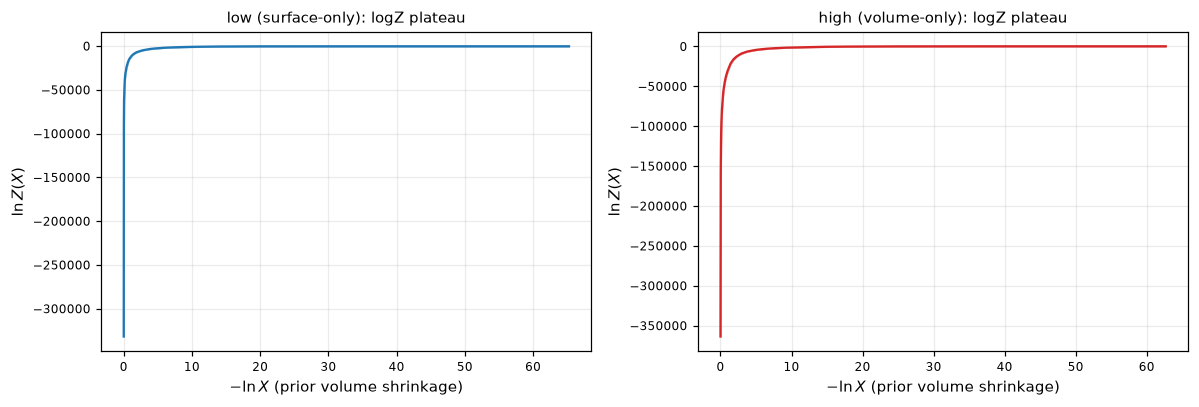

In [2]:
# --- convergence acceptance criteria -------------------------------------------------------
# These four thresholds ARE the definition of "converged" used below, so they are hoisted here
# rather than buried in the expressions that apply them.
LOGZ_TAIL_FRACTION = 0.05   # "plateaued" is judged over the last 5% of iterations
MIN_ESS = 1000              # importance-weight ESS below this is too few effective samples
BOUND_EDGE_FRACTION = 0.01  # a sample within 1% of the support range counts as "at the edge"
MIN_REPORTED_PILEUP = 0.01  # only report a parameter if >1% of its mass sits at the edge

diagnostic_rows, logz_trajectory = [], {}
for variant in chuq_io.VARIANT_NAMES:
    run = chuq_io.run_dir(variant)
    dynesty_results = np.load(run / "dynesty_results.npz")
    run_attrs = az.from_netcdf(run / "dynesty_idata.nc").posterior.attrs
    logz, logzerr, logvol, logwt, logl = (
        dynesty_results[key]
        for key in ("logz", "logzerr", "logvol", "logwt", "logl")
    )

    n_tail_iters = max(1, int(LOGZ_TAIL_FRACTION * len(logz)))

    # Effective sample size of the importance weights, as the exponentiated Shannon entropy of
    # the normalised weights. NOTE this is not the more common Kish form 1/sum(w^2): the
    # entropy version is the standard choice for nested sampling because it degrades gracefully
    # when a handful of shells dominate. The 1e-300 is an underflow guard for w = 0 exactly.
    norm_weights = np.exp(logwt - logz[-1])
    norm_weights = norm_weights / norm_weights.sum()
    ess = float(np.exp(-np.sum(norm_weights * np.log(norm_weights + 1e-300))))

    # Posterior mass sitting against the prior truncation bounds. If this is non-negligible the
    # support box, not the data, is setting the edge of the posterior -- exactly the pathology
    # that made the first low-model run bimodal in Wsew (chuq_model.PRIOR_OVERRIDES).
    # The nuisance parameter is the LAST column, appended here to match that layout.
    support_lo = np.array(
        fit_info[f"prior_lo_{variant}"] + [chuq_model.NUISANCE_BOUNDS[0]]
    )
    support_hi = np.array(
        fit_info[f"prior_hi_{variant}"] + [chuq_model.NUISANCE_BOUNDS[1]]
    )
    samples = posterior_samples[variant]
    assert samples.shape[1] == support_lo.size, "bounds/sample layout mismatch"
    edge_tol = BOUND_EDGE_FRACTION * (support_hi - support_lo)
    edge_mass_frac = np.mean(
        (samples < support_lo + edge_tol) | (samples > support_hi - edge_tol), axis=0
    )
    pileup_report = ", ".join(
        f"{name}:{frac:.0%}"
        for name, frac in zip(FREE_NAMES[variant] + ["log_ferr"], edge_mass_frac)
        if frac > MIN_REPORTED_PILEUP
    )

    diagnostic_rows.append(
        dict(
            model=variant,
            logz=float(logz[-1]),
            logzerr=float(logzerr[-1]),
            H=float(run_attrs["dynesty_information_final"]),
            niter=int(run_attrs["dynesty_niter"]),
            ncall=int(dynesty_results["ncall"].sum()),
            eff_pct=float(dynesty_results["eff"]),
            n_batches=len(dynesty_results["batch_nlive"]),
            ESS=int(round(ess)),
            draws=int(run_attrs["dynesty_posterior_draw_count"]),
            dlogz_last5pct=float(logz[-1] - logz[-1 - n_tail_iters]),
            finite=bool(
                np.isfinite(logl).all()
                and np.isfinite(dynesty_results["samples"]).all()
            ),
            bound_pileup=pileup_report or "none",
        )
    )
    logz_trajectory[variant] = (logvol, logz, logzerr)

convergence_table = pd.DataFrame(diagnostic_rows).set_index("model")
display(convergence_table)

for variant, row in convergence_table.iterrows():
    converged = (
        (row.dlogz_last5pct < row.logzerr)  # evidence stopped accumulating
        and row.finite
        and row.ESS > MIN_ESS
        and row.bound_pileup == "none"
    )
    print(
        f"{variant}: {'CONVERGED' if converged else 'CHECK FLAGS ABOVE'}"
        f"  (dlogz_last5pct={row.dlogz_last5pct:.3g} vs logzerr={row.logzerr:.3g}, "
        f"ESS={row.ESS})"
    )

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for ax, variant in zip(axes, chuq_io.VARIANT_NAMES):
    log_volume, log_evidence, log_evidence_err = logz_trajectory[variant]
    ax.plot(-log_volume, log_evidence, color=chuq_io.VARIANT_COLOR[variant])
    ax.fill_between(
        -log_volume,
        log_evidence - log_evidence_err,
        log_evidence + log_evidence_err,
        color=chuq_io.VARIANT_COLOR[variant],
        alpha=0.3,
    )
    ax.set_title(f"{variant} ({chuq_io.VARIANT_FORM[variant]}): logZ plateau")
    ax.set_xlabel(r"$-\ln X$ (prior volume shrinkage)")
    ax.set_ylabel(r"$\ln Z(X)$")
fig.tight_layout()
chuq_io.save_figure(fig, "logz_plateau")
plt.show()

## Posteriors — shared parameters overlaid, then each model's absorption params

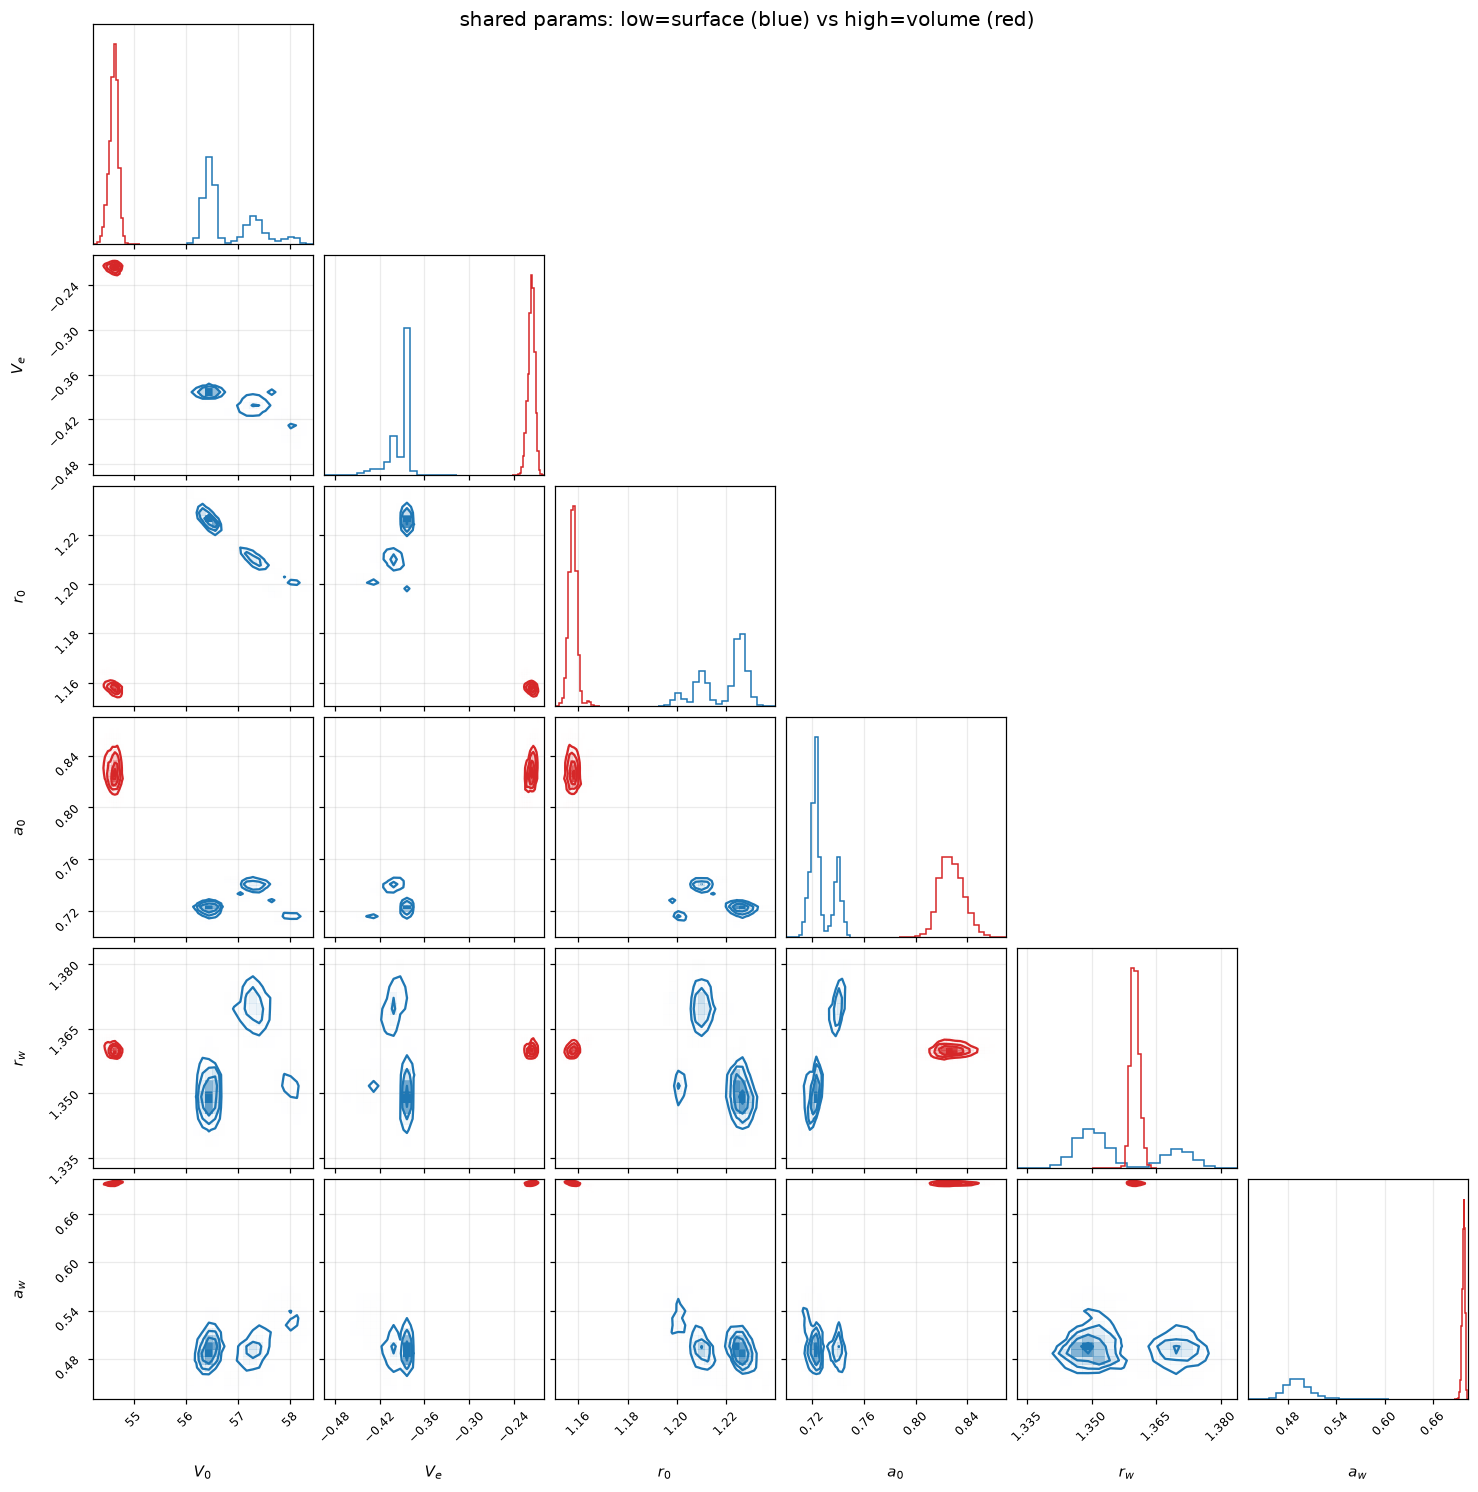

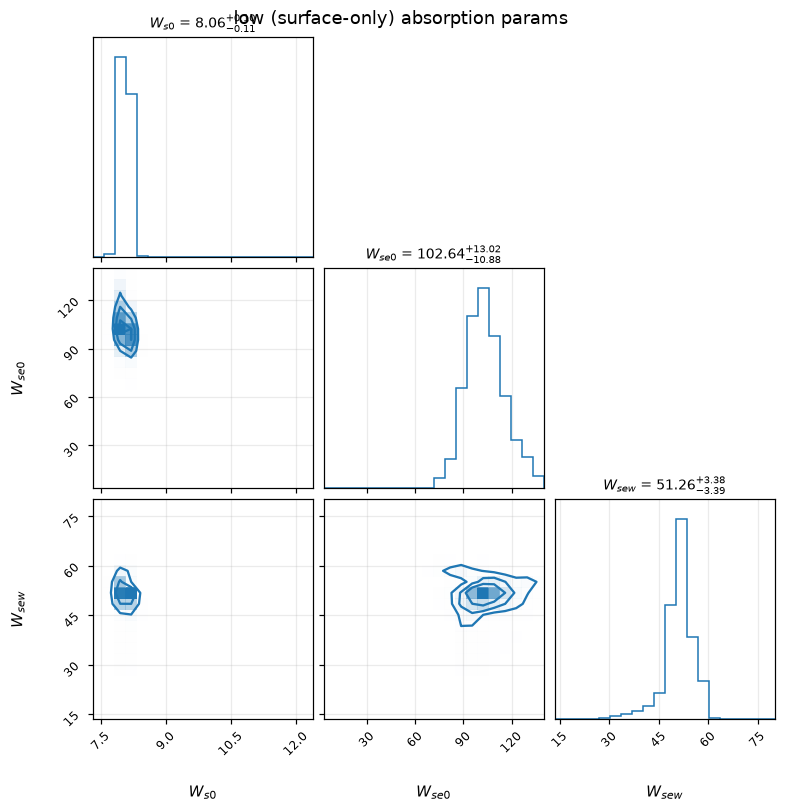

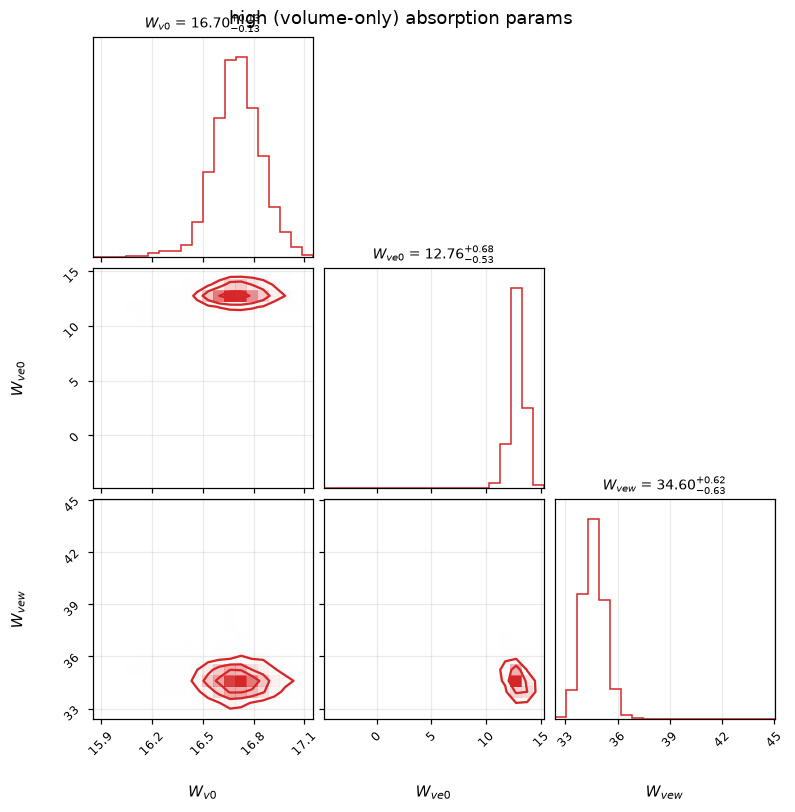

In [3]:
import corner

# (a) the six shared parameters, overlaid. Column indices differ between the variants because
# each variant's free list is ordered differently, hence the per-variant index map.
shared_col_idx = {
    v: [FREE_NAMES[v].index(p) for p in SHARED_PARAMS] for v in chuq_io.VARIANT_NAMES
}
fig = None
for variant in chuq_io.VARIANT_NAMES:
    fig = corner.corner(
        posterior_samples[variant][:, shared_col_idx[variant]],
        labels=[
            f"${chuq_model.params_of(variant)[i].latex_name}$"
            for i in shared_col_idx[variant]
        ],
        color=chuq_io.VARIANT_COLOR[variant],
        fig=fig,
        plot_datapoints=False,
        plot_density=True,
        hist_kwargs={"density": True},
    )
fig.suptitle("shared params: low=surface (blue) vs high=volume (red)", fontsize=13)
chuq_io.save_figure(fig, "corner_shared_params")
plt.show()

# (b) each variant's own active-channel absorption parameters, which have no counterpart in
# the other variant and so cannot be overlaid.
for variant in chuq_io.VARIANT_NAMES:
    absorption_col_idx = [
        i for i, name in enumerate(FREE_NAMES[variant]) if name not in SHARED_PARAMS
    ]
    fig = corner.corner(
        posterior_samples[variant][:, absorption_col_idx],
        labels=[LATEX_LABELS[variant][i] for i in absorption_col_idx],
        color=chuq_io.VARIANT_COLOR[variant],
        plot_datapoints=False,
        show_titles=True,
        title_kwargs={"fontsize": 9},
    )
    fig.suptitle(
        f"{variant} ({chuq_io.VARIANT_FORM[variant]}) absorption params", fontsize=12
    )
    chuq_io.save_figure(fig, f"corner_absorption_{variant}")
    plt.show()

## Energy-dependent depths V, W_v, W_s vs E

Each posterior sample's real-volume `V`, imag-volume `W_v`, imag-surface `W_s` depth vs `E_lab`, 68%
bands. By construction the **low** model has `W_v ≡ 0` (surface-only) and the **high** model has
`W_s ≡ 0` (volume-only), so the `W_v`/`W_s` panels each carry one model's active channel. The shaded
region `(E0, E1)` is the held-out test band, extrapolated by both.

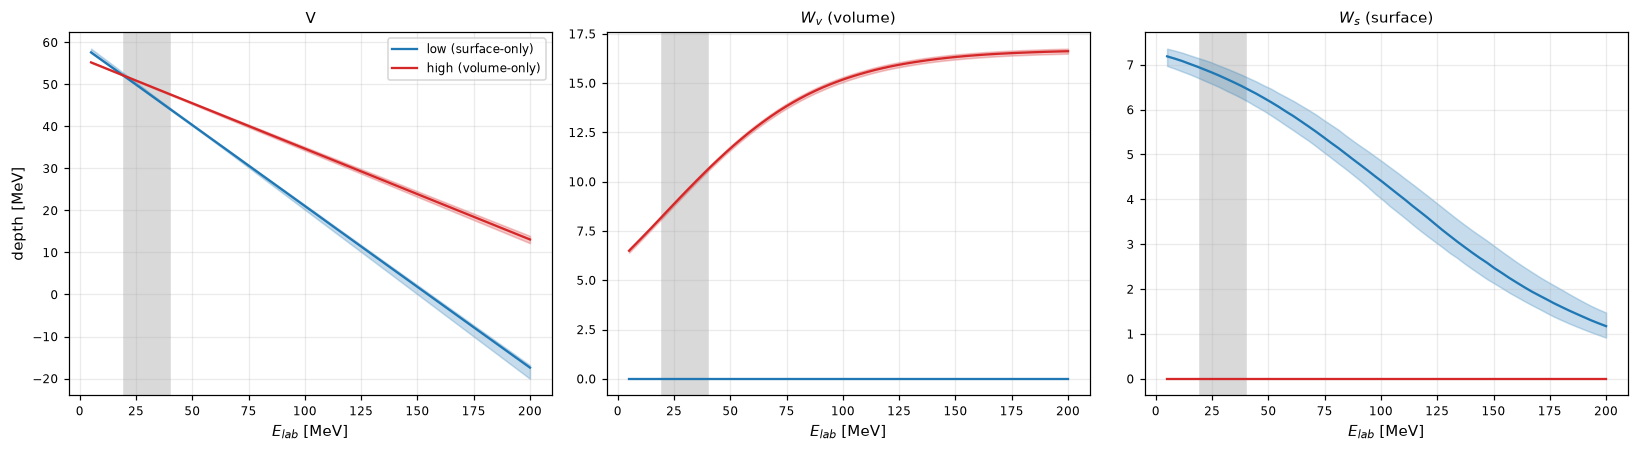

In [4]:
# --- settings ------------------------------------------------------------------------------
N_DEPTH_DRAWS = 400  # posterior draws per variant; the 16/84 band is stable well below this
DEPTH_DRAW_SEED = 0
E_GRID_MEV = np.linspace(5, 200, 60)  # spans the data range (5.4-201 MeV)

# One panel per channel returned by chuq_model.energy_dependent_depths; the labels and the
# channel count both come from chuq_model, so a potential with a different channel structure
# needs no edit in this notebook.
DEPTH_PANELS = chuq_model.DEPTH_CHANNEL_LABELS

fig, axes = plt.subplots(
    1, len(DEPTH_PANELS), figsize=(5 * len(DEPTH_PANELS), 4.2), sharex=True
)
axes = np.atleast_1d(axes)
for variant in chuq_io.VARIANT_NAMES:
    samples = posterior_samples[variant]
    draws = samples[
        np.random.default_rng(DEPTH_DRAW_SEED).choice(
            len(samples), N_DEPTH_DRAWS, replace=False
        )
    ]
    n_free = chuq_model.n_omp(variant)
    # (n_draws, n_energies, n_channels)
    depth_cube = np.array(
        [
            [
                chuq_model.energy_dependent_depths(theta[:n_free], energy, variant)
                for energy in E_GRID_MEV
            ]
            for theta in draws
        ]
    )
    assert depth_cube.shape[2] == len(DEPTH_PANELS), "channel count / label mismatch"
    for channel_idx, (ax, panel_label) in enumerate(zip(axes, DEPTH_PANELS)):
        median_depth = np.median(depth_cube[:, :, channel_idx], 0)
        q16, q84 = np.percentile(depth_cube[:, :, channel_idx], [16, 84], 0)
        ax.plot(
            E_GRID_MEV,
            median_depth,
            color=chuq_io.VARIANT_COLOR[variant],
            label=f"{variant} ({chuq_io.VARIANT_FORM[variant]})",
        )
        ax.fill_between(
            E_GRID_MEV, q16, q84, color=chuq_io.VARIANT_COLOR[variant], alpha=0.25
        )
        ax.set_title(panel_label)
        ax.set_xlabel(r"$E_{lab}$ [MeV]")

for ax in axes:
    ax.axvspan(e_split_low, e_split_high, color="0.85", zorder=0)  # held-out band
axes[0].legend()
axes[0].set_ylabel("depth [MeV]")
fig.tight_layout()
chuq_io.save_figure(fig, "depths_vs_energy")
plt.show()

## Held-out test-region comparison

Both models scored on the **same** middle-tercile data. `E_post[log L_test]` (higher = better) is the
posterior expectation of the test log-likelihood under each model; χ²/N uses the posterior-median
prediction with statistical + fitted model-error covariance.

,model,form,E_logL_test,logL_test_sd,chi2_over_n_points,model_err_frac
0,low,surface-only,-922.656,78.900,2.631,0.256
1,high,volume-only,-607.280,18.767,1.819,0.283


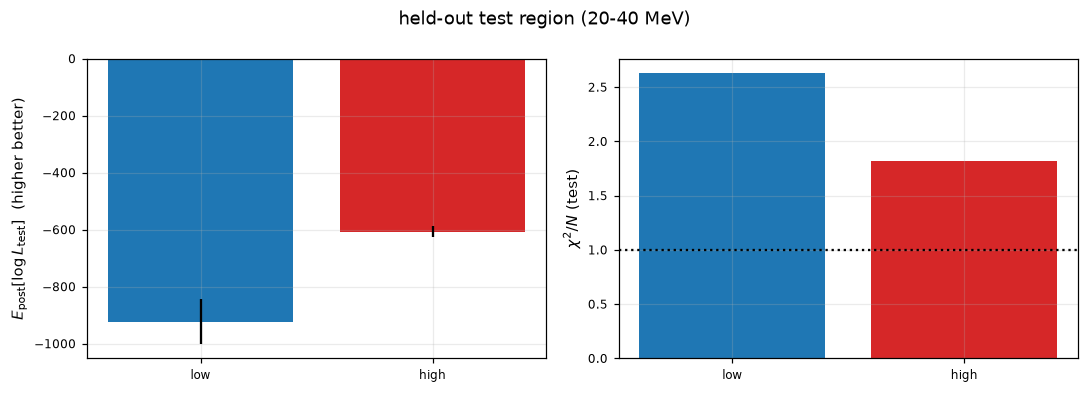

In [5]:
# --- settings ------------------------------------------------------------------------------
N_SCORE_DRAWS = 300  # posterior draws used for E_post[log L_test]
SCORE_DRAW_SEED = 1

datasets = chuq_io.load_datasets()
bands = chuq_io.split_bands(datasets, e_split_low, e_split_high)
test_datasets = bands["test"]

models_by_variant = {v: chuq_model.build_model(v) for v in chuq_io.VARIANT_NAMES}
test_evidence_by_variant = {
    v: chuq_model.build_evidence(test_datasets, models_by_variant[v])
    for v in chuq_io.VARIANT_NAMES
}

score_rows = []
for variant in chuq_io.VARIANT_NAMES:
    n_free = chuq_model.n_omp(variant)
    samples = posterior_samples[variant]
    draws = samples[
        np.random.default_rng(SCORE_DRAW_SEED).choice(
            len(samples), N_SCORE_DRAWS, replace=False
        )
    ]
    test_loglikes = np.array(
        [
            test_evidence_by_variant[variant].log_likelihood(
                theta[:n_free], [np.array([theta[n_free]])]
            )
            for theta in draws
        ]
    )
    n_nonfinite = int((~np.isfinite(test_loglikes)).sum())
    if n_nonfinite:
        # Reported rather than silently dropped: a large count would bias the mean below.
        print(f"  [{variant}] dropped {n_nonfinite}/{N_SCORE_DRAWS} non-finite log-likelihoods")
    test_loglikes = test_loglikes[np.isfinite(test_loglikes)]

    # chi^2/N at the posterior median, using the SAME variance model as the likelihood
    # (statistical + fractional model error) -- see chuq_io.predictive_variance.
    median_theta = np.median(draws, 0)
    model_err_frac = float(np.exp(median_theta[n_free]))
    chi2, n_points = 0.0, 0
    for dataset in test_datasets:
        y_model = np.asarray(models_by_variant[variant](dataset, *median_theta[:n_free]))
        y_data = np.asarray(dataset.y)
        variance = chuq_io.predictive_variance(dataset, y_model, model_err_frac)
        chi2 += np.sum((y_data - y_model) ** 2 / variance)
        n_points += y_data.size

    score_rows.append(
        dict(
            model=variant,
            form=chuq_io.VARIANT_FORM[variant],
            E_logL_test=float(np.mean(test_loglikes)),
            logL_test_sd=float(np.std(test_loglikes)),
            chi2_over_n_points=chi2 / n_points,
            model_err_frac=model_err_frac,
        )
    )

score_table = pd.DataFrame(score_rows)
display(score_table.round(3))

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
bar_colors = [chuq_io.VARIANT_COLOR[m] for m in score_table.model]
axes[0].bar(
    score_table.model,
    score_table.E_logL_test,
    yerr=score_table.logL_test_sd,
    color=bar_colors,
)
axes[0].set_ylabel(r"$E_{\rm post}[\log L_{\rm test}]$  (higher better)")
axes[1].bar(score_table.model, score_table.chi2_over_n_points, color=bar_colors)
axes[1].axhline(1, color="k", ls=":")
axes[1].set_ylabel(r"$\chi^2/N$ (test)")
fig.suptitle(f"held-out test region ({e_split_low:.0f}-{e_split_high:.0f} MeV)")
fig.tight_layout()
chuq_io.save_figure(fig, "test_region_scores")
plt.show()

## Predictive bands on the test datasets

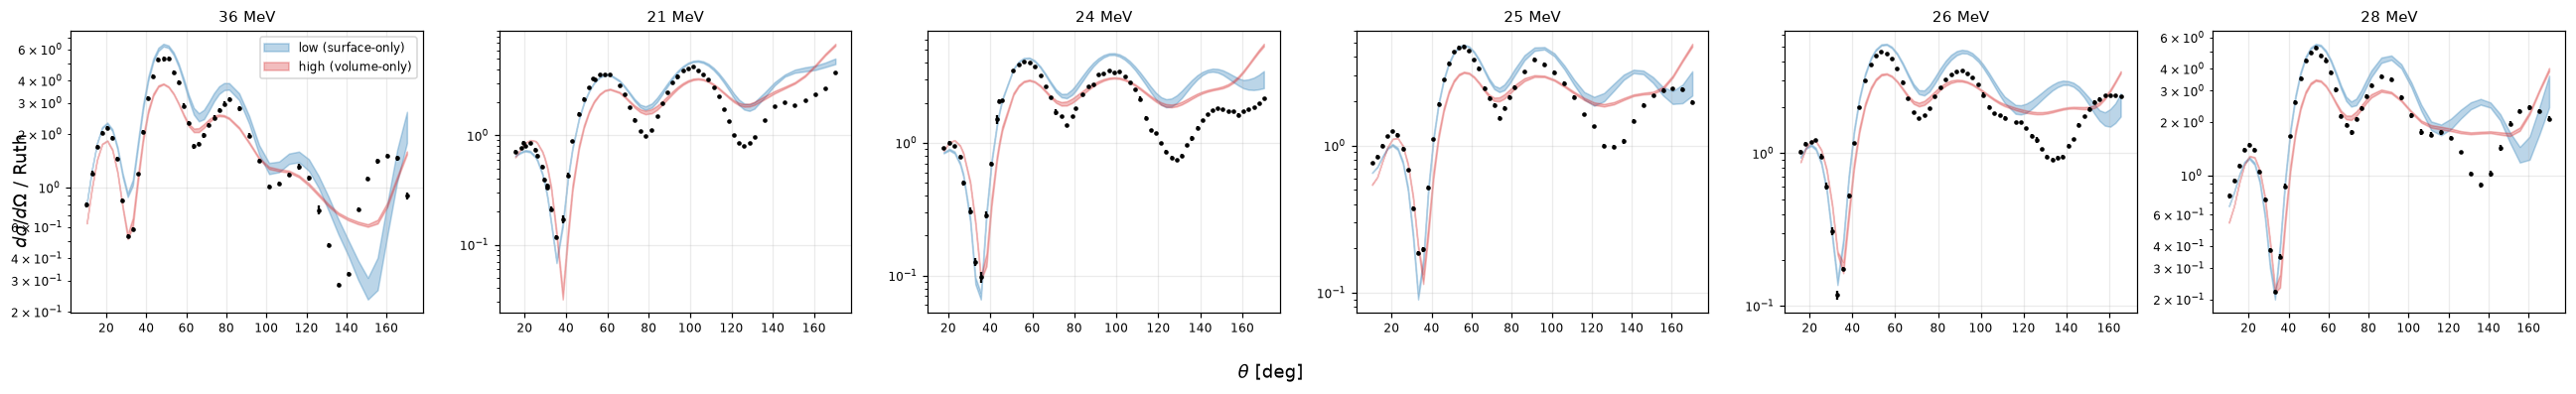

In [6]:
# --- settings ------------------------------------------------------------------------------
N_BAND_DRAWS = 200  # posterior draws per variant for the 16/84 predictive band
BAND_DRAW_SEED = 2
MAX_EXAMPLE_SETS = 6

example_test_sets = test_datasets[: min(MAX_EXAMPLE_SETS, len(test_datasets))]

fig, axes = plt.subplots(
    1, len(example_test_sets), figsize=(4 * len(example_test_sets), 3.6)
)
for ax, dataset in zip(np.atleast_1d(axes), example_test_sets):
    order = chuq_io.plot_dataset(ax, dataset, label=None)
    theta_deg = np.rad2deg(np.asarray(dataset.x))
    for variant in chuq_io.VARIANT_NAMES:
        n_free = chuq_model.n_omp(variant)
        samples = posterior_samples[variant]
        draws = samples[
            np.random.default_rng(BAND_DRAW_SEED).choice(
                len(samples), N_BAND_DRAWS, replace=False
            )
        ]
        # Model spread only (no observation noise added) -- this band shows parameter
        # uncertainty, not the full posterior predictive; chuq_coverage.ipynb does the latter.
        y_pred_draws = np.array(
            [
                np.asarray(models_by_variant[variant](dataset, *theta[:n_free]))
                for theta in draws
            ]
        )
        q16, q84 = np.percentile(y_pred_draws, [16, 84], 0)
        ax.fill_between(
            theta_deg[order],
            q16[order],
            q84[order],
            color=chuq_io.VARIANT_COLOR[variant],
            alpha=0.3,
            label=f"{variant} ({chuq_io.VARIANT_FORM[variant]})",
        )
    ax.set_title(f"{chuq_io.elab(dataset):.0f} MeV")

axes[0].legend(fontsize=8)
fig.supxlabel(r"$\theta$ [deg]")
fig.supylabel(r"$d\sigma/d\Omega\ /\ $Ruth")
fig.tight_layout()
chuq_io.save_figure(fig, "test_predictive_bands")
plt.show()

## Model-error fraction $e^{\gamma}$ posterior

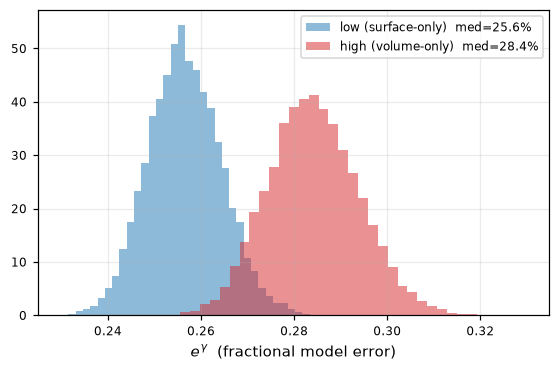

In [7]:
fig, ax = plt.subplots(figsize=(6, 3.6))
for variant in chuq_io.VARIANT_NAMES:
    # exp(gamma): the fitted fractional model error, i.e. how far the model is from the data
    # beyond statistical noise. The last posterior column is gamma = log f.
    model_err_frac = np.exp(posterior_samples[variant][:, chuq_model.n_omp(variant)])
    ax.hist(
        model_err_frac,
        bins=40,
        color=chuq_io.VARIANT_COLOR[variant],
        alpha=0.5,
        density=True,
        label=(
            f"{variant} ({chuq_io.VARIANT_FORM[variant]})  "
            f"med={np.median(model_err_frac):.1%}"
        ),
    )
ax.set_xlabel(r"$e^{\gamma}$  (fractional model error)")
ax.legend()
chuq_io.save_figure(fig, "model_error_fraction")
plt.show()